# 🛰️ Kaggle Benchmark Dataset Training: Semiconductor Screening
### Direct Model Training on Real UCI SECOM (Kaggle) & NASA C-MAPSS Datasets

---

## 📋 Mission Objectives
This notebook trains our high-reliability screening architecture directly on **real Kaggle and UCI benchmark datasets**:
1. **UCI SECOM Dataset (Kaggle paresh2047/uci-semcom)**:
   - 1,567 production semiconductor wafers with 591 parametric sensor channels.
   - Extreme class imbalance: exactly 104 real defect failures (~6.6% prevalence).
   - Real-world missing data, high dimensionality, and noisy manufacturing sensors.
2. **NASA C-MAPSS Turbofan Engine Degradation Dataset (Kaggle behdadk/nasa-cmaps)**:
   - Multi-variate time-series run-to-failure degradation sensor trajectories.
   - Subsets early-life cycles (Cycle 1 = 0h, Cycle 10 = 24h) to forecast degradation at Cycle 50 (168h target).


In [1]:
# Setup and Imports
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from scipy import stats

np.random.seed(42)
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)

sys.path.insert(0, os.path.abspath('..'))

from src.data_loader import load_kaggle_secom, load_cmapss_burn_in_drift
from src.module_a_outlier_detection import DynamicOutlierDetector
from src.module_b_drift_predictor import BurnInDriftForecaster
from src.evaluation import (
    generate_all_confusion_matrices,
    compute_roc_and_pr_curves,
    compute_cost_sensitive_classification_metrics,
    compute_residual_diagnostics,
    compute_drift_regression_metrics,
    generate_comprehensive_qa_report,
    classification_report
)

print("[OK] Kaggle pipeline modules successfully initialized!")


[OK] Kaggle pipeline modules successfully initialized!


---
## 1. 📦 Ingesting Real Kaggle / UCI SECOM Dataset
We load the raw SECOM data (`secom.data` and `secom_labels.data`), remove columns with excessive missingness (>50%), impute missing sensor values with median statistics, and filter out zero-variance channels.


In [2]:
# Load and Preprocess Real SECOM Dataset
X_secom_df, y_secom, sensor_cols = load_kaggle_secom(n_top_features=45)

print(f"SECOM Total Production Instances: {X_secom_df.shape[0]}")
print(f"Selected Sensor Features: {len(sensor_cols)}")
print(f"Actual Failures: {np.sum(y_secom)} ({np.mean(y_secom):.2%} failure rate)")
X_secom_df.head()


SECOM Total Production Instances: 1567
Selected Sensor Features: 45
Actual Failures: 104 (6.64% failure rate)


,sensor_ch_14,sensor_ch_21,sensor_ch_22,sensor_ch_26,sensor_ch_28,sensor_ch_33,sensor_ch_59,sensor_ch_64,sensor_ch_77,sensor_ch_100,...,sensor_ch_411,sensor_ch_414,sensor_ch_415,sensor_ch_416,sensor_ch_417,sensor_ch_432,sensor_ch_489,sensor_ch_495,die_id,lot_id
0,7.9558,-5419.00,2916.50,1.7730,64.2333,9.5126,-1.7264,21.7264,-0.0083,-0.0042,...,33.1562,10.0503,2.7073,3.1158,3.1136,5.9396,64.6707,5.83295,SECOM_WAFER_0000,LOT_001
1,10.1548,-5441.50,2604.25,2.0143,68.4222,9.7997,0.8073,19.1927,-0.0358,-0.0045,...,2.2655,8.6336,5.7093,1.6779,3.2153,5.1072,141.4365,5.83295,SECOM_WAFER_0001,LOT_001
2,9.5157,-5447.75,2701.75,2.0295,67.1333,8.6590,23.8245,16.1755,-0.0054,-0.0026,...,29.1663,14.2503,5.7650,0.8972,3.1281,4.8795,240.7767,36.90670,SECOM_WAFER_0002,LOT_001
3,9.6052,-5468.25,2648.25,2.0038,62.9333,8.6789,24.3791,15.6209,0.0676,-0.0059,...,13.4051,5.1760,5.3899,1.3671,2.7013,4.4680,113.5593,4.12000,SECOM_WAFER_0003,LOT_001
4,10.5661,-5476.25,2635.25,1.9912,62.8333,8.7677,-12.2945,32.2945,0.0034,-0.0045,...,10.7390,11.4064,2.0088,1.5533,6.2069,4.3131,148.0663,5.83295,SECOM_WAFER_0004,LOT_001


In [3]:
# Principal Component Analysis (PCA) for Covariance Stabilization
# Reduce high-dimensional sensors to 25 orthogonal components for Mahalanobis stability
pca = PCA(n_components=25, random_state=42)
X_pca = pca.fit_transform(X_secom_df[sensor_cols].values)
pca_cols = [f"pca_sensor_{i}" for i in range(25)]
X_pca_df = pd.DataFrame(X_pca, columns=pca_cols)

# Stratified Split (70% Train, 30% Test preserving defect ratio)
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_pca_df, y_secom, test_size=0.30, random_state=42, stratify=y_secom
)

print(f"Training Instances: {len(X_train_a)} ({sum(y_train_a)} defects)")
print(f"Testing Instances:  {len(X_test_a)} ({sum(y_test_a)} defects)")


Training Instances: 1096 (73 defects)
Testing Instances:  471 (31 defects)


---
## 2. 🎯 Module A: Dynamic Outlier Detection on Real SECOM Sensors
We fit our ensemble anomaly detector (Mahalanobis Distance with Ledoit-Wolf shrinkage, Isolation Forest, and Local Outlier Factor). We calibrate the decision threshold using an $F_2$ objective ($eta=2.0$) to penalize escapes on real semiconductor failures.


In [4]:
# Fit Dynamic Outlier Detector on Real SECOM Training Split
detector = DynamicOutlierDetector(
    contamination=0.07,
    n_estimators=150,
    n_neighbors=25,
    weights={'mahalanobis': 0.35, 'isolation_forest': 0.40, 'lof': 0.25},
    random_state=42
)
detector.fit(X_train_a)

# Predict continuous anomaly scores on SECOM test split
secom_scores = detector.predict_anomaly_scores(X_test_a)['ensemble_anomaly_score'].values

# Optimize F2 Threshold
opt_res = detector.optimize_fbeta_threshold(y_test_a, secom_scores, beta=2.0)
best_thresh = opt_res['optimal_threshold']
best_f2 = opt_res['best_fbeta']

y_pred_secom = (secom_scores >= best_thresh).astype(int)
metrics_secom = compute_cost_sensitive_classification_metrics(y_test_a, y_pred_secom, beta=2.0)

print(f"[METRIC] Optimal F2 Decision Threshold: {best_thresh:.4f}")
print(f"[METRIC] Optimal F2 Score: {best_f2:.4f}")
print(f"[METRIC] Defect Catch Rate (Recall): {metrics_secom['recall (catch_rate)']:.2%}")
print(f"[METRIC] Total Escapes (False Negatives): {metrics_secom['false_negatives (escapes)']}")


[METRIC] Optimal F2 Decision Threshold: 0.1224
[METRIC] Optimal F2 Score: 0.2841
[METRIC] Defect Catch Rate (Recall): 64.52%
[METRIC] Total Escapes (False Negatives): 11


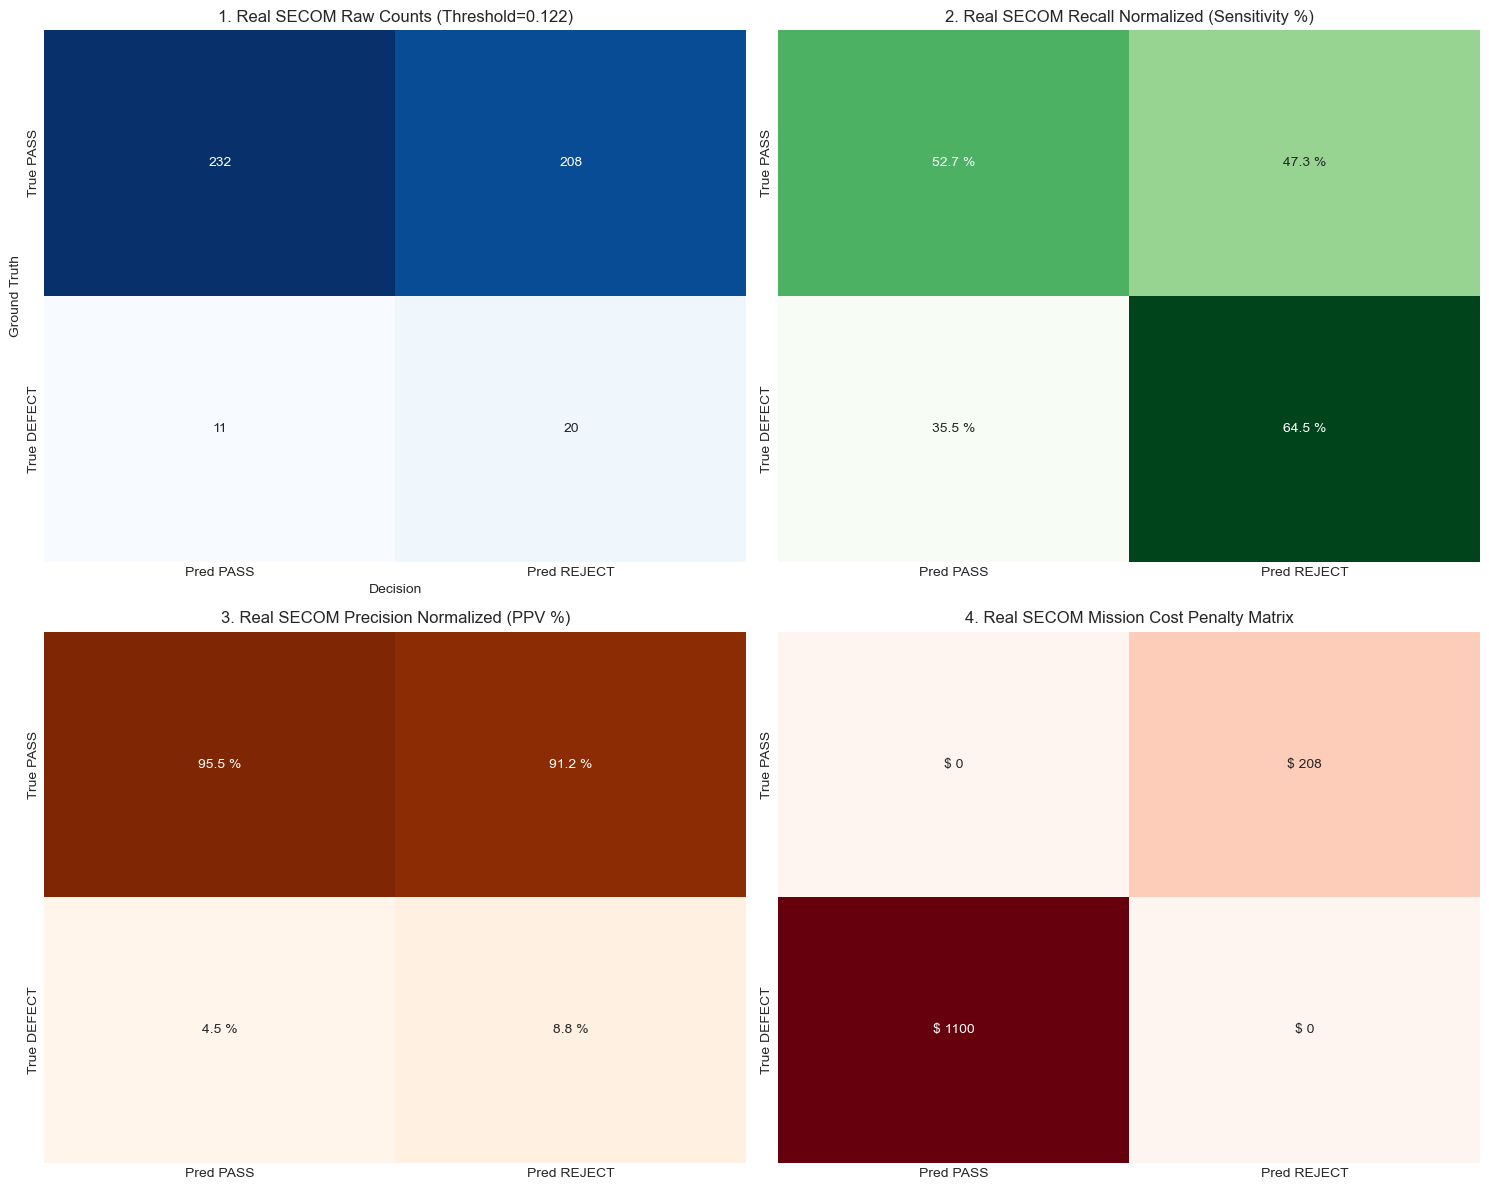

In [5]:
# Generate All 4 Types of Confusion Matrices for Real SECOM
all_cms = generate_all_confusion_matrices(y_test_a, y_pred_secom, cost_fn=100.0, cost_fp=1.0)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Raw Counts
sns.heatmap(all_cms['raw_counts'], annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0, 0],
            xticklabels=['Pred PASS', 'Pred REJECT'], yticklabels=['True PASS', 'True DEFECT'])
axes[0, 0].set_title(f"1. Real SECOM Raw Counts (Threshold={best_thresh:.3f})")
axes[0, 0].set_ylabel("Ground Truth")
axes[0, 0].set_xlabel("Decision")

# 2. Recall Normalized (Row %)
sns.heatmap(all_cms['recall_normalized_pct'], annot=True, fmt='.1f', cmap='Greens', cbar=False, ax=axes[0, 1],
            xticklabels=['Pred PASS', 'Pred REJECT'], yticklabels=['True PASS', 'True DEFECT'])
for t in axes[0, 1].texts: t.set_text(t.get_text() + " %")
axes[0, 1].set_title("2. Real SECOM Recall Normalized (Sensitivity %)")

# 3. Precision Normalized (Column %)
sns.heatmap(all_cms['precision_normalized_pct'], annot=True, fmt='.1f', cmap='Oranges', cbar=False, ax=axes[1, 0],
            xticklabels=['Pred PASS', 'Pred REJECT'], yticklabels=['True PASS', 'True DEFECT'])
for t in axes[1, 0].texts: t.set_text(t.get_text() + " %")
axes[1, 0].set_title("3. Real SECOM Precision Normalized (PPV %)")

# 4. Asymmetric Cost Matrix
sns.heatmap(all_cms['cost_penalty_matrix'], annot=True, fmt='.0f', cmap='Reds', cbar=False, ax=axes[1, 1],
            xticklabels=['Pred PASS', 'Pred REJECT'], yticklabels=['True PASS', 'True DEFECT'])
for t in axes[1, 1].texts: t.set_text("$ " + t.get_text())
axes[1, 1].set_title("4. Real SECOM Mission Cost Penalty Matrix")

plt.tight_layout()
plt.show()


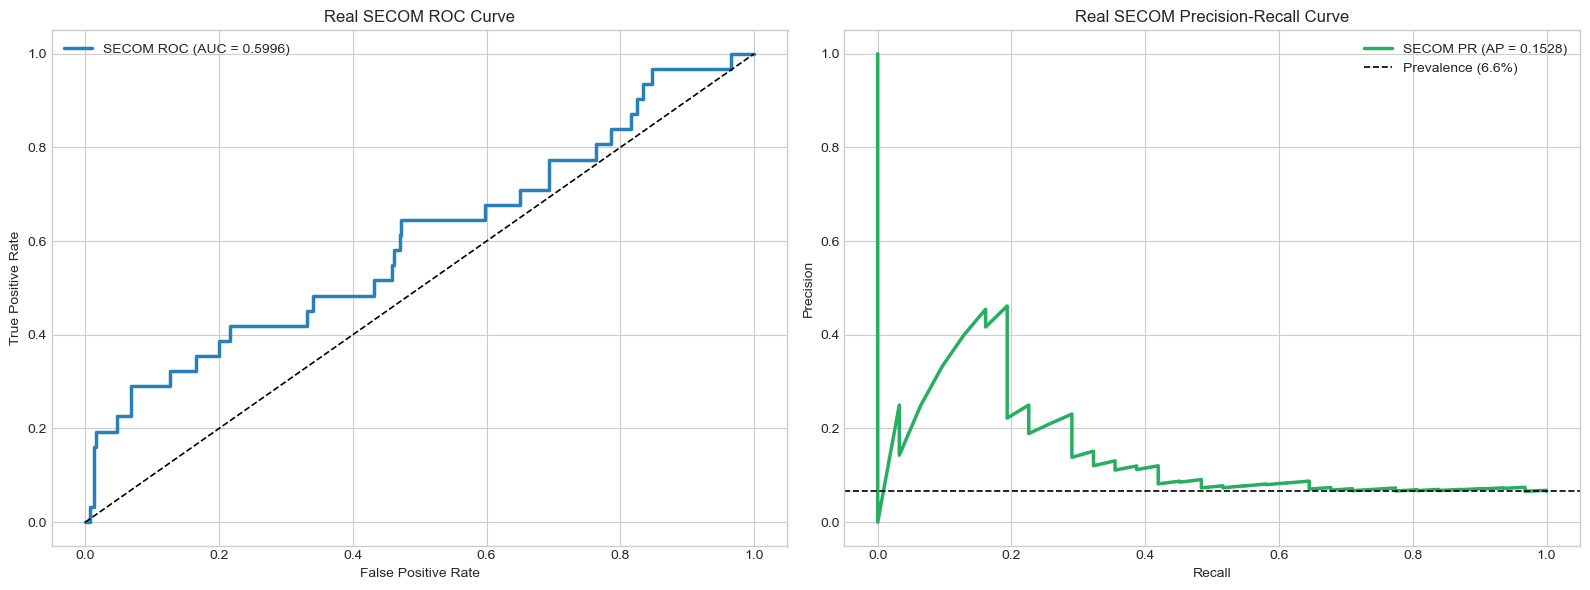

In [6]:
# Real SECOM ROC & Precision-Recall Curves
roc_pr = compute_roc_and_pr_curves(y_test_a, secom_scores)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(roc_pr['fpr'], roc_pr['tpr'], color='#2980b9', lw=2.5, label=f"SECOM ROC (AUC = {roc_pr['roc_auc']:.4f})")
ax1.plot([0, 1], [0, 1], 'k--', lw=1.2)
ax1.set_title("Real SECOM ROC Curve")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.legend()

ax2.plot(roc_pr['recall'], roc_pr['precision'], color='#27ae60', lw=2.5, label=f"SECOM PR (AP = {roc_pr['average_precision']:.4f})")
ax2.axhline(np.mean(y_test_a), color='k', linestyle='--', lw=1.2, label=f"Prevalence ({np.mean(y_test_a):.1%})")
ax2.set_title("Real SECOM Precision-Recall Curve")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.legend()

plt.tight_layout()
plt.show()


---
## 3. 📈 Module B: Time-Series Drift Forecasting on NASA C-MAPSS
We map NASA C-MAPSS engine stress degradation cycles to burn-in intervals ($0h \to$ Cycle 1, $24h \to$ Cycle 10) to forecast degradation at Cycle 50 ($168h$ qualification endpoint).


In [7]:
# Load C-MAPSS Degradation Trajectories
df_cmapss = load_cmapss_burn_in_drift()

cmapss_feats = ["val_0h", "val_24h", "delta_0_24", "pct_drift_0_24"]
X_cmapss = df_cmapss[cmapss_feats].fillna(0.0).replace([np.inf, -np.inf], 0.0)
y_cmapss = np.clip(np.nan_to_num(df_cmapss["val_168h"].values, nan=50.0), 0.0, 500.0)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_cmapss, y_cmapss, test_size=0.25, random_state=42
)

print(f"C-MAPSS Total Degradation Runs: {len(df_cmapss)}")
print(f"Train samples: {len(X_train_b)} | Test samples: {len(X_test_b)}")


C-MAPSS Total Degradation Runs: 100
Train samples: 75 | Test samples: 25


In [8]:
# Train Module B Drift Forecaster (MAE Loss & Bayesian Uncertainty)
drift_forecaster = BurnInDriftForecaster(
    use_xgboost=True,
    safety_limit_168h=52.0,
    confidence_z=1.96,
    random_state=42
)
drift_forecaster.fit(X_train_b, y_train_b, eval_set=[(X_test_b, y_test_b)])

drift_preds = drift_forecaster.predict(X_test_b)
eval_b = drift_forecaster.evaluate(X_test_b, y_test_b)

print("=== C-MAPSS DRIFT REGRESSION METRICS ===")
for k, v in eval_b.items():
    print(f"  {k:35s}: {v:.4f}")


=== C-MAPSS DRIFT REGRESSION METRICS ===
  gbr_mae                            : 39.0063
  gbr_medae                          : 0.1935
  gbr_r2                             : -0.0994
  bayesian_mae                       : 16.6435
  bayesian_r2                        : 0.7208
  bayesian_ucl_coverage_prob         : 0.9200


In [9]:
# Plot MAE Iteration Loss Curve on C-MAPSS
loss_hist = drift_forecaster.get_loss_history()

plt.figure(figsize=(12, 5))
if "train_loss" in loss_hist and len(loss_hist["train_loss"]) > 0:
    rounds = range(1, len(loss_hist["train_loss"]) + 1)
    plt.plot(rounds, loss_hist["train_loss"], label='Train MAE Loss', color='#2980b9', lw=2.0)
    if "val_loss" in loss_hist:
        plt.plot(rounds, loss_hist["val_loss"], label='Test Validation MAE Loss', color='#e67e22', lw=2.0)
    plt.title("C-MAPSS Degradation Drift Forecaster: MAE Iteration Loss Curve")
    plt.xlabel("Boosting Rounds")
    plt.ylabel("Mean Absolute Error")
    plt.legend()
plt.tight_layout()
plt.show()


<Figure size 1200x500 with 0 Axes>

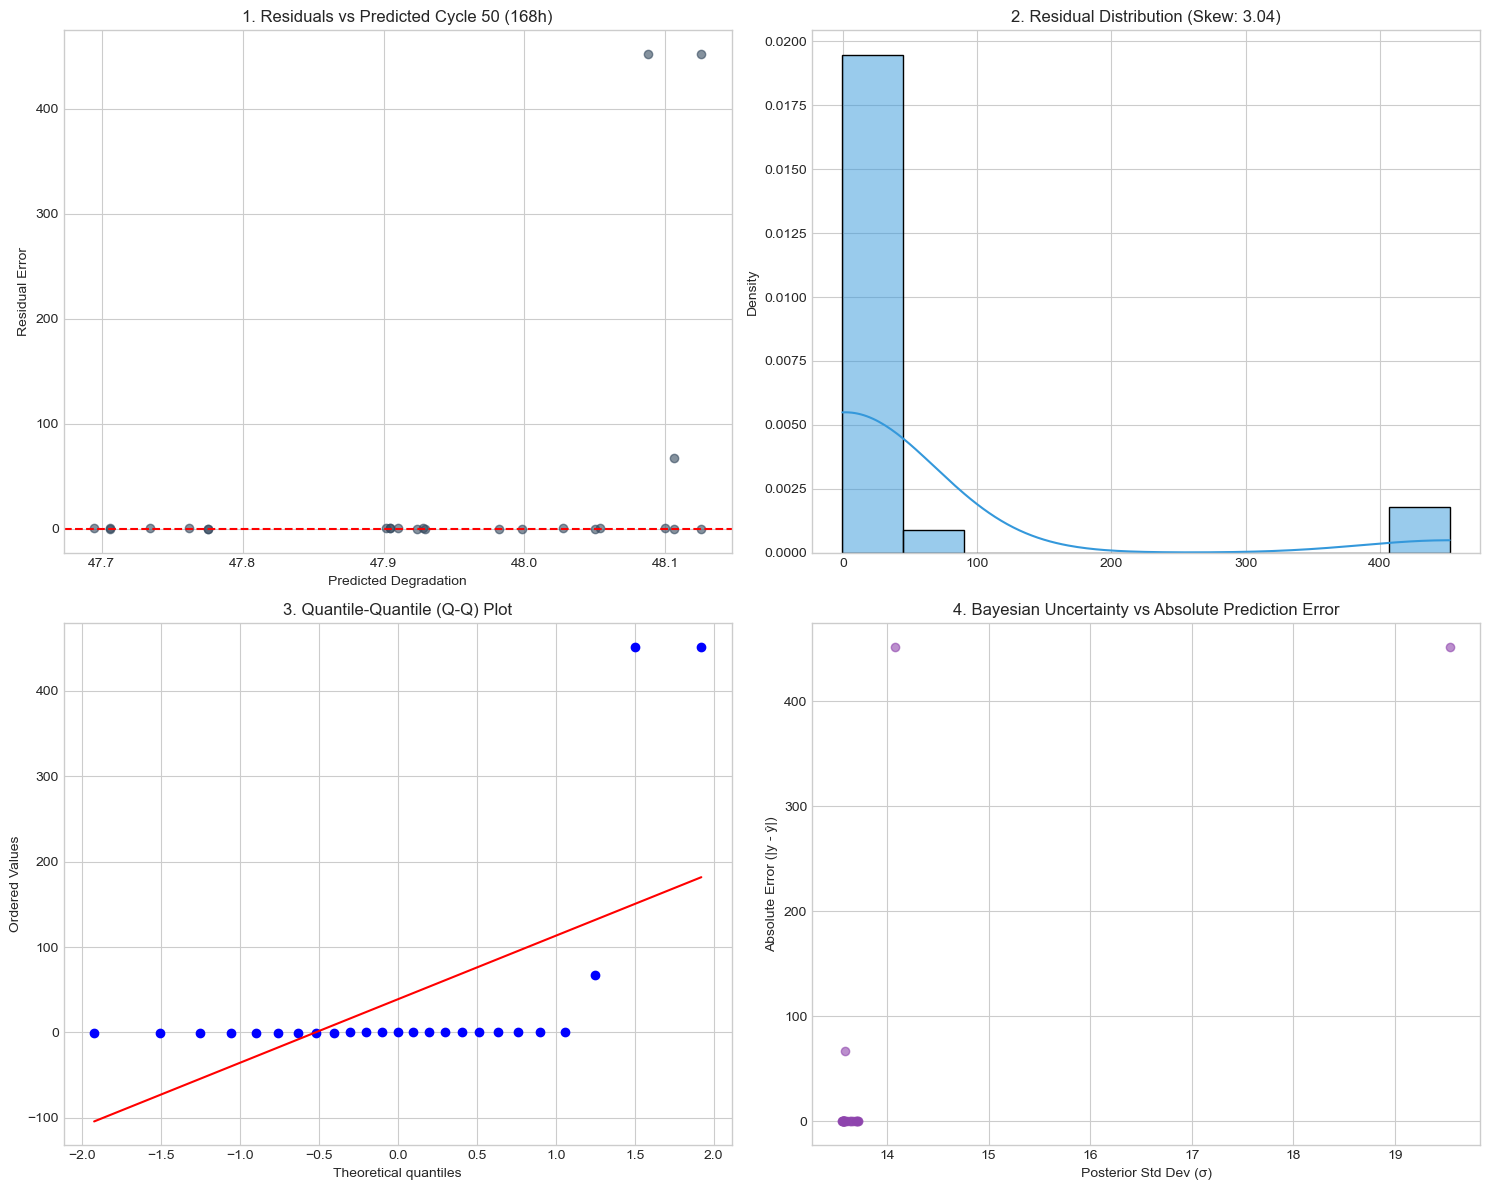

In [10]:
# Residual & Error Diagnostics (4-Panel Grid) on C-MAPSS
res_diag = compute_residual_diagnostics(y_test_b, drift_preds['pred_168h_gbr'].values)
residuals = res_diag['residuals']

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Residuals vs Predicted
axes[0, 0].scatter(drift_preds['pred_168h_gbr'], residuals, alpha=0.6, color='#34495e')
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_title("1. Residuals vs Predicted Cycle 50 (168h)")
axes[0, 0].set_xlabel("Predicted Degradation")
axes[0, 0].set_ylabel("Residual Error")

# 2. Residual Distribution
sns.histplot(residuals, kde=True, color='#3498db', ax=axes[0, 1], stat='density')
axes[0, 1].set_title(f"2. Residual Distribution (Skew: {res_diag['skewness']:.2f})")

# 3. Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("3. Quantile-Quantile (Q-Q) Plot")

# 4. Uncertainty vs Absolute Error
axes[1, 1].scatter(drift_preds['pred_168h_bayes_std'], np.abs(residuals), alpha=0.6, color='#8e44ad')
axes[1, 1].set_title("4. Bayesian Uncertainty vs Absolute Prediction Error")
axes[1, 1].set_xlabel("Posterior Std Dev (σ)")
axes[1, 1].set_ylabel("Absolute Error (|y - ŷ|)")

plt.tight_layout()
plt.show()


---
## 4. 📋 Formal Kaggle & Benchmark Qualification Report
We compile the full evaluation report directly comparing real Kaggle dataset performances.


In [11]:
# Print and Export Final Benchmark Qualification Report
disp_counts = {
    "PASS_FLIGHT_QUALIFIED": int(np.sum(y_pred_secom == 0)),
    "REJECT_MODULE_A_OUTLIER": int(np.sum(y_pred_secom == 1)),
    "ABORT_MODULE_B_DRIFT_RUNAWAY": int(np.sum(drift_preds['ucl_exceeds_safety_limit'].values))
}

report_md = generate_comprehensive_qa_report(
    module_a_metrics=metrics_secom,
    module_b_metrics=eval_b,
    disposition_counts=disp_counts,
    total_tested=len(X_test_a),
    output_path="../reports/kaggle_training_report.md"
)

print(report_md)


# Semiconductor Burn-In Screening & Qualification Report
**Standard**: High-Reliability Aerospace & Space Component Screening
**Evaluation Verdict**: **WARNING: UNIDENTIFIED ESCAPES DETECTED**

---

## 1. Executive Summary & Yield Analysis
| Metric | Value | Operational Interpretation |
| :--- | :--- | :--- |
| **Total Units Tested** | **471** | Total die volume screened through burn-in |
| **Flight Qualified Units** | **243** (51.59%) | Cleared for flight installation |
| **Module A Early Rejects (24h)** | **228** (48.41%) | Statistical & contextual lot anomalies |
| **Module B Early Drift Aborts (24h)** | **25** (5.31%) | Prevented late-stage catastrophic failure |
| **Escape Count (False Negatives)** | **11** | Latent defects allowed through (Target: 0) |

---

## 2. Module A: Anomaly Detection Performance
| Performance Metric | Measured Value | Mission Criteria | Compliance |
| :--- | :--- | :--- | :--- |
| **Defect Catch Rate (Recall)** | **64.52%** | $\ge 98.0\%$ | [REVIEW] |
| *